# Credit Card Balance Data

#### Zhenlin(Edward) Chen

In this assignment, you will create a notebook that uses data from the ISLP module and web-scraped data from Wikipedia. The goal is to extract real-world data, process it, and present it in a user-friendly format.

<div style="background-color: #fff2cc; border-left: 6px solid #f1c232; color: #000; padding: 10px;">
You may use AI to assist you in writing the code for this project, but you must link the transcripts in a references section at the bottom of the notebook. The exposition should be your own, though. 
Any code that is beyond the scope of this course should include a reference to documentation, a tutorial, or a generative AI chat.
</div>

## Part 1: Selecting a Dataset

ISLP is the Python companion to *An Introduction to Statistical Learning*. It includes several pedagogically curated datasets across domains (marketing, finance, health, etc.).

Skim the ISLP documentation: [https://islp.readthedocs.io/en/latest/index.html](https://islp.readthedocs.io/en/latest/index.html).  Open the **“Datasets used in ISLP”** page and browse the available options.

The dataset I have chosen for my project is "Credit Card Balance Data."  This is a simulated dataset used to demonstrate linear regression and other statistical modeling techniques. It contains information for 400 individuals, focusing on their credit card debt and various demographic factors. (complete this sentence with a brief description of the dataset).

The features of this dataset are... (list and describe the data features/columns).

* `Income`: Income in 1,000's
* `Limit`: Credit limit
* `Rating`: Credit rating
* `Cards`: Number of credit cards
* `Age`: Age in years
* `Education`: Education in years
* `Own`: A factor with levels No and Yes indicating whether the individual owns a home
* `Student`: A factor with levels No and Yes indicating whether the individual is a student
* `Married`: A factor with levels No and Yes indicating whether the individual is married
* `Region`: A factor with levels East, South, and West indicating the individual’s geographical location
* `Balance`: Average credit card balance in $

## Part 2: Loading Data from a Library

Install the necessary libraries:

In [138]:
!pip install ISLP beautifulsoup4 pandas

In [68]:
from ISLP import load_data
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Look at the documentation to see how to load a specific dataset

credit = load_data('Credit')
credit.columns

Index(['ID', 'Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education',
       'Gender', 'Student', 'Married', 'Ethnicity', 'Balance'],
      dtype='object')

### First five rows ###

In [131]:
# Inspect the head
credit.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


### Information ###

In [132]:
# Inspect the info
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   ID         400 non-null    int64   
 1   Income     400 non-null    float64 
 2   Limit      400 non-null    int64   
 3   Rating     400 non-null    int64   
 4   Cards      400 non-null    int64   
 5   Age        400 non-null    int64   
 6   Education  400 non-null    int64   
 7   Gender     400 non-null    category
 8   Student    400 non-null    category
 9   Married    400 non-null    category
 10  Ethnicity  400 non-null    category
 11  Balance    400 non-null    int64   
dtypes: category(4), float64(1), int64(7)
memory usage: 27.2 KB


### Description ###

In [133]:
# Describe the data
credit.describe()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,45.218885,4735.600000,354.940000,2.957500,55.667500,13.450000,520.015000
std,115.614301,35.244273,2308.198848,154.724143,1.371275,17.249807,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,21.007250,3088.000000,247.250000,2.000000,41.750000,11.000000,68.750000
50%,200.500000,33.115500,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.470750,5872.750000,437.250000,4.000000,70.000000,16.000000,863.000000
max,400.000000,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


### Rating value counts ###

In [134]:
credit["Rating"].value_counts()

Rating
344    5
287    4
383    4
296    4
339    3
      ..
200    1
269    1
511    1
283    1
415    1
Name: count, Length: 283, dtype: int64

In [135]:
# Consider other methods in pandas to explore the data
print("\nCorrelation Matrix")
credit[['Income', 'Limit', 'Education', 'Age', 'Cards', 'Rating', 'Balance']].corr()


Correlation Matrix


,Income,Limit,Education,Age,Cards,Rating,Balance
Income,1.000000,0.792088,-0.027692,0.175338,-0.018273,0.791378,0.463656
Limit,0.792088,1.000000,-0.023549,0.100888,0.010231,0.996880,0.861697
Education,-0.027692,-0.023549,1.000000,0.003619,-0.051084,-0.030136,-0.008062
Age,0.175338,0.100888,0.003619,1.000000,0.042948,0.103165,0.001835
Cards,-0.018273,0.010231,-0.051084,0.042948,1.000000,0.053239,0.086456
Rating,0.791378,0.996880,-0.030136,0.103165,0.053239,1.000000,0.863625
Balance,0.463656,0.861697,-0.008062,0.001835,0.086456,0.863625,1.000000


This dataset This dataset reveals an extremely strong correlation (0.99) between "rating" (i.e., credit score) and "limit" (i.e., credit limit). Furthermore, "income" and "balance" are also demonstrates strong associations with both "limit" and "rating". One point that surprised me, however, was that education appears to have virtually no impact on the rating; typically, individuals with more education tend to engage in more rational consumption behaviors, thereby possessing relatively higher credit scores.


(In this Markdown cell, pose a guiding question you plan to answer using this data and explain why the question is relevant.)

How do you get a high credit limit?

## Part 3: Scraping Data from Wikipedia

The wikipedia page I have chosen is https://en.wikipedia.org/wiki/Credit_score_in_the_United_States, April 27, 2026 (complete this sentence with the URL of the Wikipedia page and the date accessed).

This website explains the components of a credit score, which helps me analyze it with a focused approach.

The wikipedia page I have chosen is https://en.wikipedia.org/wiki/Credit_limit, April 27, 2026 (complete this sentence with the URL of the Wikipedia page and the date accessed).

This website explains the relationship between a credit score and a credit limit, helping to clarify which of the two is the dependent factor.

In [129]:
# Scrape the data
import requests
import pandas as pd
from bs4 import BeautifulSoup
from io import StringIO
url = (" https://en.wikipedia.org/wiki/Credit_score_in_the_United_States")
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'} # Adapted from https://coderslegacy.com/beautifulsoup-user-agents/#google_vignette
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, 'html.parser')
table = soup.find('table', {'class': 'wikitable'})


In [130]:
url2 = ("https://en.wikipedia.org/wiki/Credit_limit")
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}# Adapted from https://coderslegacy.com/beautifulsoup-user-agents/#google_vignette
credit_limit = requests.get(url2, headers=headers)

# Adapted from https://gemini.google.com/app/54afbab9284d7f08
response2 = requests.get(url2, headers=headers)
soup = BeautifulSoup(credit_limit.content, 'html.parser')
tables = soup.find_all('table', {'class': 'wikitable'})
credit_limit_table = None
for t in tables:
    if "Superprime" in t.get_text():
        credit_limit_table = t
        break
if credit_limit_table:
    df_limit = pd.read_html(StringIO(str(credit_limit_table)))[0]
    print("Table successfully loaded!")
    display(df_limit.head())
else:
    print("Could not find the table. Double-check the search string.")


Table successfully loaded!


,Credit score tier (FICO),General-purpose card,Private-label card
0,Superprime (800 or higher),"$12,529","$3,714"
1,Prime plus (720-799),"$9,428","$3,366"
2,Prime (660-719),"$5,587","$2,486"
3,Near-prime (620-659),"$3,067","$1,617"
4,Subprime (580-619),"$2,059","$1,225"


In [127]:
# Clean the data
crdit_limit_table["Credit score tier (FICO)"] = df_limit["Credit score tier (FICO)"].str.replace(r',|\$', "", regex=True)
crdit_limit_table["General-purpose card"] = df_limit["General-purpose card"].str.replace(r',|\$', "", regex=True)
crdit_limit_table["Private-label card"] = df_limit["Private-label card"].str.replace(r',|\$', "", regex=True)

In [75]:
# Present the scraped data
# Adapted from https://gemini.google.com/app/fefad4f4377a84ee
data = {
    'Weight (%)': [35, 30, 15, 10, 10],
    'Category': [
        'Payment History', 
        'Amounts Owed', 
        'Length of Credit History', 
        'Credit Mix', 
        'New Credit'
    ],
    'Key Factors': [
        'On-time payments, bankruptcies, collections',
        'Credit utilization ratio, total debt balances',
        'Age of oldest and newest accounts',
        'Variety of loans (Credit cards, Mortgages, Auto)',
        'Recent hard inquiries and account openings'
    ]
}
credit_score = pd.DataFrame(data)
credit_score

,Weight (%),Category,Key Factors
0,35,Payment History,"On-time payments, bankruptcies, collections"
1,30,Amounts Owed,"Credit utilization ratio, total debt balances"
2,15,Length of Credit History,Age of oldest and newest accounts
3,10,Credit Mix,"Variety of loans (Credit cards, Mortgages, Auto)"
4,10,New Credit,Recent hard inquiries and account openings


In [122]:
crdit_limit_table = pd.DataFrame(columns=["Tier", "General", "Private"])
for row in credit_limit_table.find_all("tr")[1:]:
    col = row.find_all("td")
    tier = col[0].text
    general = col[1].text
    private = col[2].text
    crdit_limit_table = pd.concat([crdit_limit_table,pd.DataFrame({"Tier":[tier], "General":[general], "Private":[private]})], ignore_index=True)
crdit_limit_table.head(6)

,Tier,General,Private
0,Superprime (800 or higher),"$12,529","$3,714\n"
1,Prime plus (720-799),"$9,428","$3,366\n"
2,Prime (660-719),"$5,587","$2,486\n"
3,Near-prime (620-659),"$3,067","$1,617\n"
4,Subprime (580-619),"$2,059","$1,225\n"
5,Deep subprime (579 or lower),"$1,521",$998\n


The data from wikipedia complements the ISLP dataset by... (write a brief summary of how the Wikipedia data relates to your ISLP dataset. What new information does it provide? How will it enhance your analysis


The first Wikipedia page provided me with a breakdown of the components that make up a credit score, thereby enabling me to gain a clearer understanding of which factors have the most significant impact on improving it. From this, I observed that the "amount owed" accounts for nearly one-third of the total—making it the second-largest component of a credit score—which serves as an excellent explanation for the strong correlation between one's outstanding balance, credit rating, and credit limit.

The second Wikipedia page displayed the credit limits corresponding to various credit score tiers, thereby demonstrating a direct correlation between the two: as the credit score rises, the credit limit increases—exhibiting a nearly exponential growth pattern. This observation also serves as a strong reflection of the 0.99 correlation coefficient between them.

## Part 4: Visualizing and Analyzing the Data

### Visualization 1

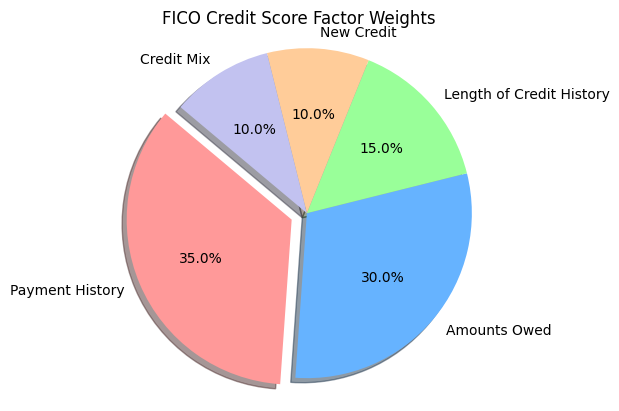

In [77]:
# Code for visualization 1
# Adapted from https://gemini.google.com/app/fefad4f4377a84ee
import matplotlib.pyplot as plt

# Data for the FICO score weights
labels = [
    'Payment History', 
    'Amounts Owed', 
    'Length of Credit History', 
    'New Credit', 
    'Credit Mix'
]
sizes = [35, 30, 15, 10, 10]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

# "Explode" the largest slice to highlight it
explode = (0.1, 0, 0, 0, 0)  

# Create the pie chart
plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=140, colors=colors)

# Ensure the pie is a circle
plt.axis('equal')  
plt.title('FICO Credit Score Factor Weights')

# Display or save the chart
plt.savefig('fico_pie_chart.png', bbox_inches='tight')

(Visualization 1 description and analysis)

This graoh illustrates the various components of a credit score and their respective weightings, utilizing distinct colors to highlight the differences between them. As the graph reveals, payment history and the amount owed exert the most significant influence on a credit score; therefore, anyone seeking to substantially improve their score should focus their efforts primarily on these two areas. The remaining three components also warrant attention: avoiding the opening of too many new lines of credit, as well as managing various types of debt within a short timeframe helps to maintain one's current credit score. While building a long-term credit history contributes to the steady, gradual improvement of one's credit score.

### Visualization 2

In [80]:
!pip install seaborn matplotlib

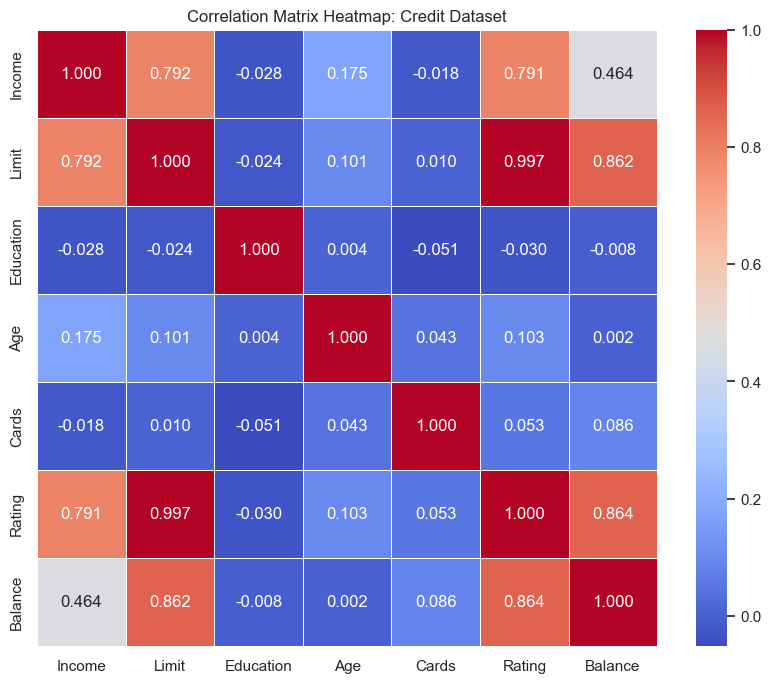

In [126]:
# Code for visualization 2
# Adapted from https://gemini.google.com/app/fefad4f4377a84ee
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the numerical columns you want to correlate
# (Matching the columns from your screenshot)
cols_to_show = ['Income', 'Limit', 'Education', 'Age', 'Cards', 'Rating', 'Balance']
corr_matrix = credit_df[cols_to_show].corr()

# 2. Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      # Show the numeric values in the cells
            cmap='coolwarm', # Red for positive, Blue for negative correlation
            fmt=".3f",       # Format to 3 decimal places
            linewidths=0.5)

plt.title('Correlation Matrix Heatmap: Credit Dataset')
plt.show()

(Visualization 2 description and analysis)

This visualization effectively utilizes both color and data to clearly illustrate the interrelationships among various metrics. It reveals an exceptionally strong positive correlation between *rating* and *limit*. *Balance* also exhibits a strong positive correlation with both *rating* and *limit*; similarly, *income* demonstrates a significant positive correlation with *limit* and *rating*, while not quite as pronounced as that of *balance*, the difference is marginal. However, although a positive correlation exists between *income* and *balance*, its magnitude is relatively weak. The correlations among all other factors are virtually negligible. Consequently, it is evident that one can approach the improvement of both *rating* and *limit* from two key angles: increasing income and maintaining a high balance. When considered in conjunction with previous visualizations, this suggests that individuals should utilize their available credit within their financial means while simultaneously working to increase their income, thereby establishing a virtuous cycle that fosters the simultaneous growth of both their credit rating and credit limit.

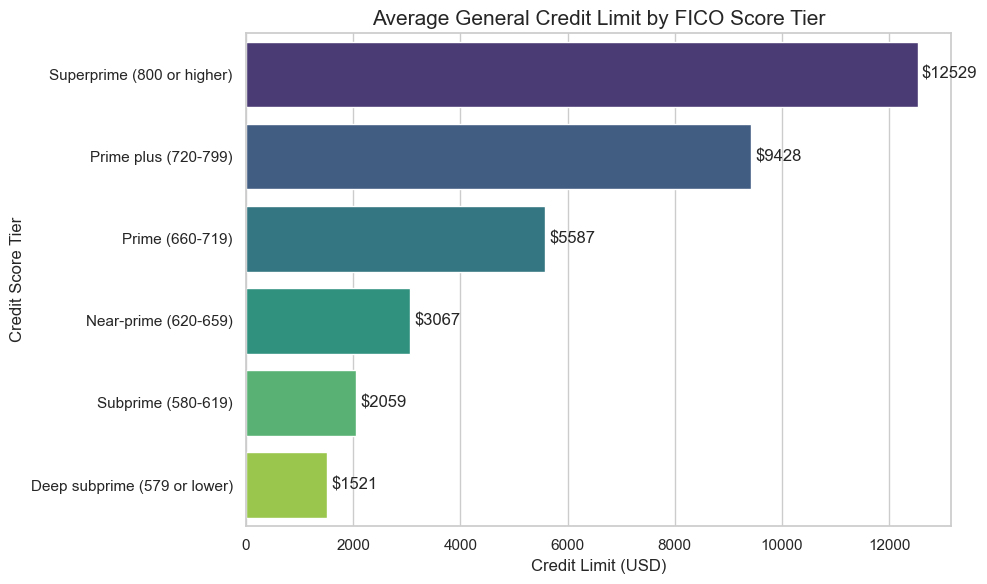

In [123]:
# Adapted from https://gemini.google.com/app/54afbab9284d7f08
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the data to ensure it's numeric for the plot
# We remove $, commas, and the \n characters found in your screenshot
df_plot = crdit_limit_table.copy()
df_plot['General'] = df_plot['General'].replace(r'[\$,\n]', '', regex=True).astype(float)
df_plot['Private'] = df_plot['Private'].replace(r'[\$,\n]', '', regex=True).astype(float)

# 2. Set the aesthetic style
sns.set_theme(style="whitegrid")

# 3. Create the Bar Chart
plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x='General', 
    y='Tier', 
    data=df_plot, 
    palette='viridis', 
    hue='Tier', 
    legend=False
)

# 4. Add labels and title
plt.title('Average General Credit Limit by FICO Score Tier', fontsize=15)
plt.xlabel('Credit Limit (USD)', fontsize=12)
plt.ylabel('Credit Score Tier', fontsize=12)

# Add value labels on the bars for clarity
for i in barplot.containers:
    barplot.bar_label(i, padding=3, fmt='$%.0f')

plt.tight_layout()
plt.show()

(Visualization 3 description and analysis)

This chart primarily illustrates the relationship between the credit limits of general-purpose credit cards and credit scores across various tiers. The bar graph serves to visualize the disparities between these different stages more clearly. As the chart demonstrates, the differences in credit limits among the lowest three tiers are relatively minor; however, a substantial gap emerges starting from the transition between the third and fourth tiers. Consequently, obtaining a high credit limit necessitates belonging to the upper tiers—which, in turn, implies the need to improve one's credit score.

## Part 5: Executive Summary

(Write an executive summary.)

To begin with, I raised the issue: "How do you get a high credit limit?" From the study conducted with different variables, it emerged that the most important variable which helps one obtain a high credit limit is being in the high credit score category, a position which can only be attained by having a high credit score.  Since a credit score is made up of many variables, people have to be careful with both short and long term activities if they are to maintain good credit ratings   Examples of measures that will help here are but not limited to obtaining significant loans according to one's ability and repaying the loans as quickly as possible; through such an action, one improves his/her ratio of credit utilization, payments history and the amounts owing.  In addition to the above, it is also necessary for one to start building credit as early as possible since the action raises one's length of credit history and hence credit score.  At the same time, one should be careful about creating too many accounts of varying kinds in short periods; through such steps, one avoids raising the number of inquiries, hence keeping one's credit profile steady.  Since the present analysis was based mostly on the correlation between “amounts owed” and credit scores, and since the “payment history” is the most significant factor in a credit score, it will be highly beneficial for future studies to concentrate on this particular aspect. Through comparative analysis among different loans, future studies will find out what kind of financial behaviors have the most impact on credit scores, particularly behaviors that improve credit scores and behaviors that must be avoided to ensure that credit scores do not deteriorate.

## Part 6: References

* https://islp.readthedocs.io/en/latest/datasets/Credit.html 
* https://en.wikipedia.org/wiki/Credit_score_in_the_United_States 
* https://en.wikipedia.org/wiki/Credit_limit
* https://coderslegacy.com/beautifulsoup-user-agents/
* https://gemini.google.com/app/54afbab9284d7f08
* https://gemini.google.com/app/fefad4f4377a84ee

# Submission requirements

**🗑️ Delete this instruction cell after completing the instruction below.**

- Appropriate file name: `lastname-project.ipynb`, replacing `lastname` with your actual last name.
- The title and your name at the top of the notebook.
- Instructions cells deleted so that only your work remains.
- Notebook runs without errors from top to bottom.
- All visualizations are rendered correctly.
- At least three unique visualizations with explanations.
- At least 250 words in the executive summary.
- References are properly cited.

Next week, you will present your research and associated dashboard to the class in a Presentation Forum, similar to what you participated in during the first course. Be prepared to discuss your data source, the challenges you faced, and how you solved them.
